# Notebook 03 · Transferability — Hanoi & HCMC (**Sentinel-2 median**)

The Sentinel-2 counterpart of `02_Transferability_Vietnam_v2.ipynb`. Same design
throughout; **only the predictor differs** — 64 AlphaEarth dimensions
(`A00..A63`) become 10 S2 median bands (`B2..B12`), built by the same
`s2_utils.build_composite` used in notebooks 00 and 01b.

## Pipeline

| Cell | Does |
|---|---|
| 1 | Config, load Milan model |
| 2 | Helpers — reclass, spatial blocks |
| 3 | Per city: GHSL → sample → composite → split → Scenario A & B |
| 3b–6 | Split figure, comparison table, scatter, per-class metrics |
| 7 | GEE raster export |
| 8–9 | Summary, observed-vs-predicted maps |

## Setup

| | |
|---|---|
| model | **RF** — matching notebook 02, so metrics compare directly |
| Milan reference | `outputs_S2_median/best_model_RF_S2.joblib` (RF @ 500m, holdout RMSE 11.29) |
| predictor | 10 S2 median bands; per-city dates from notebook 00b |
| sampling / split | unchanged from notebook 02 |

**Scenario A** applies the Milan model directly. **Scenario B** retrains locally
with spatial block CV.

## Read before interpreting results

**Median, not percentile.** Percentiles need ≥ 17 dates; the 2018 L2A archive
holds 10 over Hanoi and 16 over HCMC — short before any screening, so no
threshold could reach it. Median has no minimum. Full record in
`00b_S2_Extraction_Vietnam_2018.ipynb`.

**The composites are thin:**

| | dates | obs/pixel | vs Milan |
|---|---|---|---|
| Milan | 30 | ~30 | — |
| Hanoi | 4 | 3.82 | 13% |
| HCMC | 3 | 2.66 | 9% |

Both sides use the same method and bands, so the comparison is structurally
fair — but the Milan median came from ~30 looks per pixel and Vietnam's from
3–4. **If Scenario A transfers poorly, composite depth and genuine transfer
failure are confounded**; rule depth out before concluding anything about the
predictor. Cell 1 prints per-city depth.

These are also **dry-season** composites — 6–7 months of 2018 have no imagery
over these AOIs. Not annual.

> Prerequisite: run `00b_S2_Extraction_Vietnam_2018.ipynb` first.

---
## Cell 1 · Imports & configuration

In [1]:
# ── Interpreter + PROJ check -- RUN THIS FIRST ──────────────────────────────
# Two environment problems on this machine, both fatal to the next cells:
#
# 1. Wrong kernel. C:\Python312 is on PATH and has no `ee`/`geemap`.
#
# 2. PROJ conflict. The system PROJ_LIB points at a PostGIS proj.db whose
#    layout version is 2, while rasterio needs >= 5 -- so Cell 3's
#    `ghsl.rio.reproject()` dies with `CRSError: The EPSG code is unknown`.
#
#    The fix is to UNSET PROJ_LIB/PROJ_DATA, not to repoint them: rasterio
#    and pyproj bundle DIFFERENT PROJ builds here (rasterio's proj.db is
#    layout 1.5, pyproj's is 1.4), so any single global value satisfies one
#    and breaks the other. Unset, each library finds its own.
#
# Must run before rasterio/geopandas are imported -- hence its own cell.
import sys, os

print('interpreter :', sys.executable)
print('version     :', sys.version.split()[0])
if os.path.join('IMD-Mapping', '.venv') not in sys.executable:
    print()
    print('*** WRONG KERNEL ***')
    print('    VS Code: click the kernel name (top right) -> Select Another')
    print('    Kernel -> Python Environments -> .venv (3.11.4)')

for _v in ('PROJ_LIB', 'PROJ_DATA'):
    _old = os.environ.pop(_v, None)
    if _old:
        print(f'cleared {_v}: {_old}')

# Prove an EPSG code resolves before Cell 3 depends on it.
import rasterio.crs
import pyproj
try:
    rasterio.crs.CRS.from_epsg(32648)          # UTM 48N -- the Vietnam zone
    pyproj.CRS.from_epsg(32648)
    print('PROJ check  : OK (EPSG:32648 resolves in rasterio and pyproj)')
except Exception as _e:
    print('PROJ check  : FAILED --', str(_e)[:200])

interpreter : D:\06_Polimi\2025-2026\IMD-Mapping\.venv\Scripts\python.exe
version     : 3.11.4
cleared PROJ_LIB: D:\01_Software\PostgreSQL\share\contrib\postgis-3.3\proj
PROJ check  : OK (EPSG:32648 resolves in rasterio and pyproj)


In [2]:
import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
import geedim as gd
import rioxarray as rxr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree
import warnings, os, time, json
import joblib
from shapely.geometry import box

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone

# Same helper as notebooks 00b and 01b -- mask/composite definitions must not
# drift between the notebook that picked the dates and the one that samples them.
from s2_utils import S2_BANDS, build_composite

warnings.filterwarnings('ignore')
# ee.Authenticate()  # run once
ee.Initialize(project='ee-xiaoo-503606')

# ── Configuration ─────────────────────────────────────────────────────────────
GEE_PROJECT       = 'ee-xiaoo-503606'
S2_YEAR           = 2018
N_CLASSES         = 7
RANDOM_STATE      = 42
N_JOBS            = -1
N_CV_FOLDS        = 5
N_ITER_RF         = 30
SAMPLES_PER_CLASS = 500
BBOX_HALF         = 15000      # 30 km x 30 km clip
SPLIT_BLOCK_M     = 1000       # block size for spatial train/test split
BUFFER_M          = 250        # buffer between train and test blocks

# ── Sentinel-2 predictor ──────────────────────────────────────────────────────
# 'median', not 'percentile' -- see header. Must match both the Milan run being
# transferred and the 00b screening; asserted below rather than trusted.
S2_COLLECTION    = 'COPERNICUS/S2_SR_HARMONIZED'
COMPOSITE_METHOD = 'median'

# ── City centres ──────────────────────────────────────────────────────────────
# Identical to notebook 02, so both runs' metrics describe the same ground.
CITIES = {
    'Hanoi': {
        'centre_lonlat': (105.85, 21.03),
        'utm_crs':       'EPSG:32648',
        'ghsl_path':     './data/IMD_2018_Hanoi.tif',
        'dates_meta':    f'./samples_S2_{COMPOSITE_METHOD}_Hanoi/s2_extraction_metadata.json',
    },
    'HCMC': {
        'centre_lonlat': (106.70, 10.78),
        'utm_crs':       'EPSG:32648',
        'ghsl_path':     './data/IMD_2018_HCMC.tif',
        'dates_meta':    f'./samples_S2_{COMPOSITE_METHOD}_HCMC/s2_extraction_metadata.json',
    },
}

# ── Milan reference model (S2 median run) -- READ ONLY ────────────────────────
# Written by 01b cell 34; same contract notebook 02 uses against ./outputs_v2.
MILAN_DIR        = f'./outputs_S2_{COMPOSITE_METHOD}'
MILAN_MODEL_PATH = f'{MILAN_DIR}/best_model_RF_S2.joblib'
MILAN_META_PATH  = f'{MILAN_DIR}/model_metadata_S2.json'
MILAN_TRAIN_PTS  = f'{MILAN_DIR}/spatial_train_pts.gpkg'

OUTPUT_DIR = f'./outputs_transfer_S2_{COMPOSITE_METHOD}'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})
CLASS_COLORS = ['#2166ac','#74add1','#abd9e9','#fee090','#f46d43','#d73027','#a50026']
CLASS_LABELS = ['C0 (0%)','C1 (1-20%)','C2 (21-40%)',
                'C3 (41-60%)','C4 (61-80%)','C5 (81-99%)','C6 (100%)']
IMD_PALETTE  = ['#1a9641','#a6d96a','#ffffbf','#fdae61','#d7191c']

# Load Milan model + metadata
milan_model = joblib.load(MILAN_MODEL_PATH)
with open(MILAN_META_PATH) as f:
    milan_meta = json.load(f)
band_names = milan_meta['band_names']

# Band names alone cannot identify a run: pin the composite identity, or a model
# trained on one composite gets applied to another with plausible metrics.
assert milan_meta.get('method') == COMPOSITE_METHOD, (
    f"{MILAN_META_PATH} records method {milan_meta.get('method')!r}, "
    f'expected {COMPOSITE_METHOD!r}.')
assert band_names == list(S2_BANDS), (
    f'Median band names must be the 10 raw S2 bands, got {band_names}.')

# Every city needs its own screened dates -- notebook 00b writes them.
for _city, _cfg in CITIES.items():
    if not os.path.exists(_cfg['dates_meta']):
        raise FileNotFoundError(
            f"No date selection for {_city}: {_cfg['dates_meta']}\n"
            'Run 00b_S2_Extraction_Vietnam_2018.ipynb first -- Milan\'s dates '
            'do not exist over Vietnam.')

print(f'Milan model loaded: {milan_meta["best_model_name"]} '
      f'@ block {milan_meta["best_block"]}')
print(f'   predictor: {milan_meta["predictor"]} | method={milan_meta["method"]}')
print(f'   bands: {len(band_names)} | Milan holdout RMSE: '
      f'{milan_meta["holdout_rmse"]:.2f}%')
print(f'   Milan dates: {len(milan_meta["selected_dates"])}')

# ── Composite depth -- print it before any metric ────────────────────────────
print('\nVietnam composite depth (Milan: 30 dates, ~30 obs/pixel):')
for _city, _cfg in CITIES.items():
    with open(_cfg['dates_meta']) as _f:
        _m = json.load(_f)
    _obs = _m.get('obs_per_pixel') or sum(
        d['valid%'] for d in _m['per_date_stats']) / 100
    print(f'  {_city:6s} {len(_m["selected_dates"]):2d} dates  {_obs:5.2f} '
          f'obs/pixel ({_obs / 30 * 100:3.0f}% of Milan)  '
          f'months {_m.get("months_composited", [])}')
print('  Thin -- a transfer gap may be depth, not the predictor. Rule it out.')

print(f'\nOutput -> {OUTPUT_DIR}')

Milan model loaded: RF @ block 500m
   predictor: Sentinel-2 L2A | method=median
   bands: 10 | Milan holdout RMSE: 11.29%
   Milan dates: 30

Vietnam composite depth (Milan: 30 dates, ~30 obs/pixel):
  Hanoi   4 dates   3.82 obs/pixel ( 13% of Milan)  months [1, 3, 10, 12]
  HCMC    3 dates   2.66 obs/pixel (  9% of Milan)  months [2, 12]
  Thin -- a transfer gap may be depth, not the predictor. Rule it out.

Output -> ./outputs_transfer_S2_median


---
## Cell 2 · Helper functions

Includes reclassification, spatial block assignment, buffer, and train/test split — same design as Notebook 01c.

In [3]:
def reclass_imd_7(arr):
    """Reclassify continuous IMD (0-100) into 7 classes matching Milan."""
    out = np.full_like(arr, -1, dtype=np.int8)
    out[arr == 0]                  = 0
    out[(arr > 0)  & (arr <= 20)]  = 1
    out[(arr > 20) & (arr <= 40)]  = 2
    out[(arr > 40) & (arr <= 60)]  = 3
    out[(arr > 60) & (arr <= 80)]  = 4
    out[(arr > 80) & (arr < 100)]  = 5
    out[arr == 100]                = 6
    return out

# ── Spatial block helpers (same as 01c) ───────────────────────────────────────
def assign_blocks(coords, block_size):
    bx = (coords[:, 0] // block_size).astype(int)
    by = (coords[:, 1] // block_size).astype(int)
    return np.array([f'{x}_{y}' for x, y in zip(bx, by)])

def blocks_to_folds(block_ids, n_folds, seed):
    rng    = np.random.RandomState(seed)
    unique = rng.permutation(np.unique(block_ids))
    bmap   = {b: i % n_folds for i, b in enumerate(unique)}
    return np.array([bmap[b] for b in block_ids]), bmap

def apply_buffer(train_coords, test_coords, buffer_m):
    if len(train_coords) == 0 or buffer_m == 0:
        return np.ones(len(test_coords), dtype=bool)
    dists, _ = cKDTree(train_coords).query(test_coords, k=1)
    return dists > buffer_m

def make_spatial_splits(point_folds, n_folds):
    all_idx = np.arange(len(point_folds))
    return [(all_idx[point_folds != f], all_idx[point_folds == f])
            for f in range(n_folds)]

def spatial_train_test_split(coords, test_frac, block_size, buffer_m, seed):
    """Split point array into train/test using spatial blocks.
    Returns train_mask, test_mask (after buffer), keep_test boolean mask."""
    block_ids  = assign_blocks(coords, block_size)
    unique_blk = np.unique(block_ids)
    rng        = np.random.RandomState(seed)
    shuffled   = rng.permutation(unique_blk)
    n_total    = len(coords)
    test_blocks = set()
    n_accum     = 0
    for blk in shuffled:
        if n_accum / n_total >= test_frac:
            break
        test_blocks.add(blk)
        n_accum += (block_ids == blk).sum()
    test_block_mask  = np.array([b in test_blocks for b in block_ids])
    train_block_mask = ~test_block_mask
    keep_test = apply_buffer(coords[train_block_mask], coords[test_block_mask], buffer_m)
    return train_block_mask, test_block_mask, keep_test

print('Helper functions defined.')


Helper functions defined.


---
## Cell 3 · Process each city

GHSL clip → 500 pts/class → S2 median composite → extract 10 bands → spatial
train/test split → **Scenario A** (Milan transfer) → **Scenario B** (local
retrain, spatial CV).

In [4]:
city_results = {}

for city_name, cfg in CITIES.items():
    print('\n' + '='*60)
    print(f'   CITY: {city_name}')
    print('='*60)

    # ── 1. Compute bbox ────────────────────────────────────────────────────────
    lon, lat = cfg['centre_lonlat']
    centre_gdf = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy([lon], [lat]), crs='EPSG:4326'
    ).to_crs(cfg['utm_crs'])
    cx, cy = centre_gdf.geometry.x[0], centre_gdf.geometry.y[0]
    bbox_utm  = box(cx-BBOX_HALF, cy-BBOX_HALF, cx+BBOX_HALF, cy+BBOX_HALF)
    bbox_4326 = gpd.GeoSeries([bbox_utm], crs=cfg['utm_crs']).to_crs('EPSG:4326').iloc[0]
    aoi_ee    = ee.Geometry.Polygon([[list(c) for c in bbox_4326.exterior.coords]])
    print(f'  BBOX: {2*BBOX_HALF/1000:.0f} x {2*BBOX_HALF/1000:.0f} km')

    # ── 2. Load + clip GHSL ────────────────────────────────────────────────────
    ghsl = rxr.open_rasterio(cfg['ghsl_path'], masked=True).squeeze('band', drop=True)
    if str(ghsl.rio.crs) != cfg['utm_crs']:
        ghsl = ghsl.rio.reproject(cfg['utm_crs'])
    ghsl_clip = ghsl.rio.clip(gpd.GeoSeries([bbox_utm], crs=cfg['utm_crs']), all_touched=True)
    ghsl_arr  = ghsl_clip.values
    ghsl_cls  = reclass_imd_7(ghsl_arr)
    print(f'  GHSL clipped: {ghsl_clip.shape} | range: {float(ghsl_clip.min()):.1f}-{float(ghsl_clip.max()):.1f}%')

    # ── 3. Build the S2 median composite ──────────────────────────────────────
    # build_composite already applies the ESA WorldCover water mask, clips to
    # the AOI and pins band order via select(band_names) -- so the inline water
    # mask and manual updateMask that the embedding version needed are gone.
    with open(cfg['dates_meta']) as f:
        city_meta = json.load(f)
    city_dates = city_meta['selected_dates']

    # median has no minimum date count -- that is why it is the method here.
    # The number that matters is depth per PIXEL, not the date count: partial
    # swaths inflate the latter while contributing almost nothing to the former.
    city_obs = sum(d['valid%'] for d in city_meta['per_date_stats']) / 100
    assert len(city_dates) > 0, f'{city_name}: no dates. Re-run notebook 00b.'

    pred_img, s2_proj, city_bands = build_composite(
        S2_COLLECTION, city_dates, aoi_ee, method=COMPOSITE_METHOD)

    # The feature-column contract. If the city composite's bands disagree with
    # the Milan model's, Scenario A would feed the classifier columns it was
    # never trained on -- silently, and with plausible-looking metrics.
    assert city_bands == band_names, (
        f'{city_name}: composite bands disagree with the Milan model.\n'
        f'  here ({len(city_bands)}): {city_bands[:4]} ...\n'
        f'  meta ({len(band_names)}): {band_names[:4]} ...')

    print(f'  S2 dates: {len(city_dates)} ({city_dates[0]} ... {city_dates[-1]})'
          f' | rung {city_meta.get("escalation_rung", "?")}')
    print(f'  S2 bands: {len(city_bands)} ({COMPOSITE_METHOD})')
    print(f'  Composite depth: {city_obs:.2f} obs/pixel '
          f'({city_obs/30*100:.0f}% of Milan\'s ~30) -- thin, see header')

    # ── 4. Sample 500/class stratified ────────────────────────────────────────
    print(f'  Sampling {SAMPLES_PER_CLASS} pts/class...')
    np.random.seed(RANDOM_STATE)
    transform  = ghsl_clip.rio.transform()
    sample_pts = []
    for c in range(N_CLASSES):
        ys, xs = np.where(ghsl_cls == c)
        if len(ys) == 0:
            continue
        idx = np.random.choice(len(ys), min(SAMPLES_PER_CLASS, len(ys)), replace=False)
        for i in idx:
            x = transform[0] * xs[i] + transform[2] + transform[0]/2
            y = transform[4] * ys[i] + transform[5] + transform[4]/2
            sample_pts.append((x, y, float(ghsl_arr[ys[i], xs[i]]), c))
    sample_df  = pd.DataFrame(sample_pts, columns=['x_utm','y_utm','IMD','IMD_class'])
    sample_gdf = gpd.GeoDataFrame(
        sample_df,
        geometry=gpd.points_from_xy(sample_df['x_utm'], sample_df['y_utm']),
        crs=cfg['utm_crs']
    ).to_crs('EPSG:4326')
    print(f'  Total sampled: {len(sample_gdf)} pts')

    # ── 5. Extract S2 median values at sample points ──────────────────────────
    print(f'  Extracting S2 bands at sample points...')
    fc_pts = ee.FeatureCollection([
        ee.Feature(ee.Geometry.Point([row.geometry.x, row.geometry.y]),
                   {'IMD': float(row['IMD']), 'IMD_class': int(row['IMD_class'])})
        for _, row in sample_gdf.iterrows()
    ])
    samples_with_s2 = pred_img.sampleRegions(
        collection=fc_pts, properties=['IMD','IMD_class'],
        scale=10, projection=s2_proj, tileScale=4, geometries=True
    )
    t0 = time.time()
    samples_full = geemap.ee_to_gdf(samples_with_s2)
    print(f'  S2 download: {time.time()-t0:.1f}s | rows: {len(samples_full)}')

    # The S2 composite is masked wherever no selected date was clear, so this
    # drops more points than the embedding version did. The loss is NOT random
    # -- residual cloud clusters spatially -- so a large shortfall breaks the
    # uniform 500/class design rather than merely shrinking it.
    n_before = len(samples_full)
    samples_full = samples_full.dropna(subset=band_names).reset_index(drop=True)
    samples_full['IMD_class'] = samples_full['IMD_class'].astype(int)
    retention = 100 * len(samples_full) / max(n_before, 1)
    print(f'  After NaN drop: {len(samples_full)} pts '
          f'({retention:.1f}% retained)')
    if retention < 90:
        print(f'  *** WARNING: {100-retention:.1f}% of points lost to masking. '
              'Masked pixels cluster on residual cloud, so the surviving '
              'sample is no longer uniform across classes -- check the '
              'per-class counts below before trusting the metrics. ***')
    print('  Class counts after drop: ' +
          ', '.join(f'C{c}={int((samples_full["IMD_class"]==c).sum())}'
                    for c in range(N_CLASSES)))

    # ── 6. Spatial train/test split ────────────────────────────────────────────
    # Reproject to UTM for metric block assignment
    smp_utm = samples_full.to_crs(cfg['utm_crs'])
    coords_smp = np.column_stack([smp_utm.geometry.x, smp_utm.geometry.y])

    train_block_mask, test_block_mask, keep_test = spatial_train_test_split(
        coords_smp, test_frac=0.30, block_size=SPLIT_BLOCK_M,
        buffer_m=BUFFER_M, seed=RANDOM_STATE
    )
    train_idx = np.where(train_block_mask)[0]
    test_idx  = np.where(test_block_mask)[0][keep_test]

    X_all   = samples_full[band_names].values.astype(np.float32)
    y_all   = samples_full['IMD'].values.astype(np.float32)
    cls_all = samples_full['IMD_class'].values.astype(int)

    X_tr    = X_all[train_idx];   y_tr  = y_all[train_idx];  cls_tr = cls_all[train_idx]
    X_te    = X_all[test_idx];    y_te  = y_all[test_idx];   cls_te = cls_all[test_idx]
    coords_tr = coords_smp[train_idx]
    coords_te = coords_smp[test_idx]

    print(f'  Spatial split ({SPLIT_BLOCK_M}m blocks, {BUFFER_M}m buffer):')
    print(f'    Train: {len(train_idx)} | Test (after buffer): {len(test_idx)}')
    print(f'    Buffer removed: {(~keep_test).sum()} pts ({100*(~keep_test).sum()/test_block_mask.sum():.1f}%)')

    # ── 7. SCENARIO A -- Milan model transfer ──────────────────────────────────
    print(f'\n  -- Scenario A: Milan model transfer --')
    y_pred_zs = np.clip(milan_model.predict(X_te), 0, 100)
    metrics_zs = {
        'RMSE': float(np.sqrt(mean_squared_error(y_te, y_pred_zs))),
        'MAE':  float(mean_absolute_error(y_te, y_pred_zs)),
        'R2':   float(r2_score(y_te, y_pred_zs)),
        'Bias': float(np.mean(y_te - y_pred_zs)),
    }
    print(f'    RMSE={metrics_zs["RMSE"]:.2f}%  MAE={metrics_zs["MAE"]:.2f}%  ' +
          f'R2={metrics_zs["R2"]:.3f}  Bias={metrics_zs["Bias"]:+.2f}%')

    # ── 8. SCENARIO B -- Local retrain RF with spatial CV ──────────────────────
    print(f'\n  -- Scenario B: Local retrain RF (spatial {N_CV_FOLDS}-fold CV) --')

    # Compute spatial folds on training points, try 3 block sizes, pick best
    param_space = {
        'n_estimators':      [100, 200, 300, 500],
        'max_depth':         [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 2, 4],
        'max_features':      ['sqrt', 'log2', 0.3, 0.5],
        'bootstrap':         [True, False],
        'max_samples':       [None, 0.7, 0.8, 0.9],
    }
    CV_BLOCK_SIZES = [500, 1000, 2000]
    best_rmse_tune = np.inf
    best_search    = None
    best_cv_block  = None

    for bs in CV_BLOCK_SIZES:
        bids = assign_blocks(coords_tr, bs)
        pf, _ = blocks_to_folds(bids, N_CV_FOLDS, RANDOM_STATE)
        cv_splits = make_spatial_splits(pf, N_CV_FOLDS)
        print(f'    {bs}m spatial CV ... ', end='', flush=True)
        t0 = time.time()
        search = RandomizedSearchCV(
            estimator           = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS),
            param_distributions = param_space,
            n_iter              = N_ITER_RF,
            cv                  = cv_splits,
            scoring             = 'neg_root_mean_squared_error',
            n_jobs              = N_JOBS,
            random_state        = RANDOM_STATE,
            refit               = True
        )
        search.fit(X_tr, y_tr)
        cv_rmse = -search.best_score_
        print(f'{time.time()-t0:.1f}s | CV RMSE={cv_rmse:.3f}')
        if cv_rmse < best_rmse_tune:
            best_rmse_tune = cv_rmse
            best_search    = search
            best_cv_block  = bs

    local_rf = best_search.best_estimator_
    print(f'    Best CV block: {best_cv_block}m | CV RMSE={best_rmse_tune:.3f}')
    print(f'    Best params: {best_search.best_params_}')

    y_pred_lr = np.clip(local_rf.predict(X_te), 0, 100)
    metrics_lr = {
        'RMSE': float(np.sqrt(mean_squared_error(y_te, y_pred_lr))),
        'MAE':  float(mean_absolute_error(y_te, y_pred_lr)),
        'R2':   float(r2_score(y_te, y_pred_lr)),
        'Bias': float(np.mean(y_te - y_pred_lr)),
    }
    print(f'    RMSE={metrics_lr["RMSE"]:.2f}%  MAE={metrics_lr["MAE"]:.2f}%  ' +
          f'R2={metrics_lr["R2"]:.3f}  Bias={metrics_lr["Bias"]:+.2f}%')

    joblib.dump(local_rf, f'{OUTPUT_DIR}/local_rf_{city_name}.joblib')

    # ── Export train/test points separately ─────────────────────────────────
    samples_train = samples_full.iloc[train_idx].reset_index(drop=True)
    samples_test  = samples_full.iloc[test_idx].reset_index(drop=True)
    samples_train.to_file(f'{OUTPUT_DIR}/samples_{city_name}_train.gpkg', driver='GPKG')
    samples_test.to_file(f'{OUTPUT_DIR}/samples_{city_name}_test.gpkg', driver='GPKG')
    print(f'    Saved: samples_{city_name}_train.gpkg ({len(samples_train)} pts), '
          f'samples_{city_name}_test.gpkg ({len(samples_test)} pts)')

    city_results[city_name] = {
        'bbox_utm':      (cx-BBOX_HALF, cy-BBOX_HALF, cx+BBOX_HALF, cy+BBOX_HALF),
        'utm_crs':       cfg['utm_crs'],
        'ghsl_clip':     ghsl_clip,
        'ghsl_cls':      ghsl_cls,
        'samples':       samples_full,
        'samples_train': samples_train,
        'samples_test':  samples_test,
        'coords_tr':     coords_tr,
        'coords_te':     coords_te,
        'X_tr':          X_tr,   'y_tr':  y_tr,  'cls_tr': cls_tr,
        'X_te':          X_te,   'y_te':  y_te,  'cls_te': cls_te,
        'y_pred_zs':     y_pred_zs,
        'y_pred_lr':     y_pred_lr,
        'metrics_zs':    metrics_zs,
        'metrics_lr':    metrics_lr,
        'local_rf':      local_rf,
        'best_params':   best_search.best_params_,
        'best_cv_block': best_cv_block,
        'cv_rmse_tune':  best_rmse_tune,
        'pred_img':      pred_img,
        'aoi_ee':        aoi_ee,
        's2_proj':       s2_proj,
        's2_dates':      city_dates,
        's2_obs_per_px': city_obs,
        'train_idx':     train_idx,
        'test_idx':      test_idx,
        'block_mask_rem': (~keep_test).sum(),
    }

print('\nBoth cities processed.')



   CITY: Hanoi
  BBOX: 30 x 30 km


  GHSL clipped: (3001, 3001) | range: 0.0-100.0%
  S2 dates: 4 (2018-01-19 ... 2018-12-20) | rung 2
  S2 bands: 10 (median)
  Composite depth: 3.82 obs/pixel (13% of Milan's ~30) -- thin, see header
  Sampling 500 pts/class...


  Total sampled: 3500 pts
  Extracting S2 bands at sample points...


  S2 download: 59.2s | rows: 3423
  After NaN drop: 3423 pts (100.0% retained)
  Class counts after drop: C0=435, C1=492, C2=498, C3=499, C4=500, C5=499, C6=500
  Spatial split (1000m blocks, 250m buffer):
    Train: 2387 | Test (after buffer): 895
    Buffer removed: 141 pts (13.6%)

  -- Scenario A: Milan model transfer --
    RMSE=37.15%  MAE=28.93%  R2=-0.142  Bias=-23.79%

  -- Scenario B: Local retrain RF (spatial 5-fold CV) --
    500m spatial CV ... 

18.3s | CV RMSE=24.188
    1000m spatial CV ... 

...

  S2 download: 55.3s | rows: 3379
  After NaN drop: 3379 pts (100.0% retained)
  Class counts after drop: C0=400, C1=481, C2=499, C3=499, C4=500, C5=500, C6=500
  Spatial split (1000m blocks, 250m buffer):
    Train: 2362 | Test (after buffer): 887
    Buffer removed: 130 pts (12.8%)

  -- Scenario A: Milan model transfer --
    RMSE=35.19%  MAE=26.98%  R2=0.042  Bias=-23.18%

  -- Scenario B: Local retrain RF (spatial 5-fold CV) --
    500m spatial CV ... 

14.0s | CV RMSE=23.620
    1000m spatial CV ... 

13.6s | CV RMSE=23.933
    2000m spatial CV ... 

13.3s | CV RMSE=23.599
    Best CV block: 2000m | CV RMSE=23.599
    Best params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_samples': 0.9, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': True}
    RMSE=22.88%  MAE=17.93%  R2=0.595  Bias=-1.90%
    Saved: samples_HCMC_train.gpkg (2362 pts), samples_HCMC_test.gpkg (887 pts)



Both cities processed.


---
## Cell 3b · Figure 0 — Spatial train/test split per city

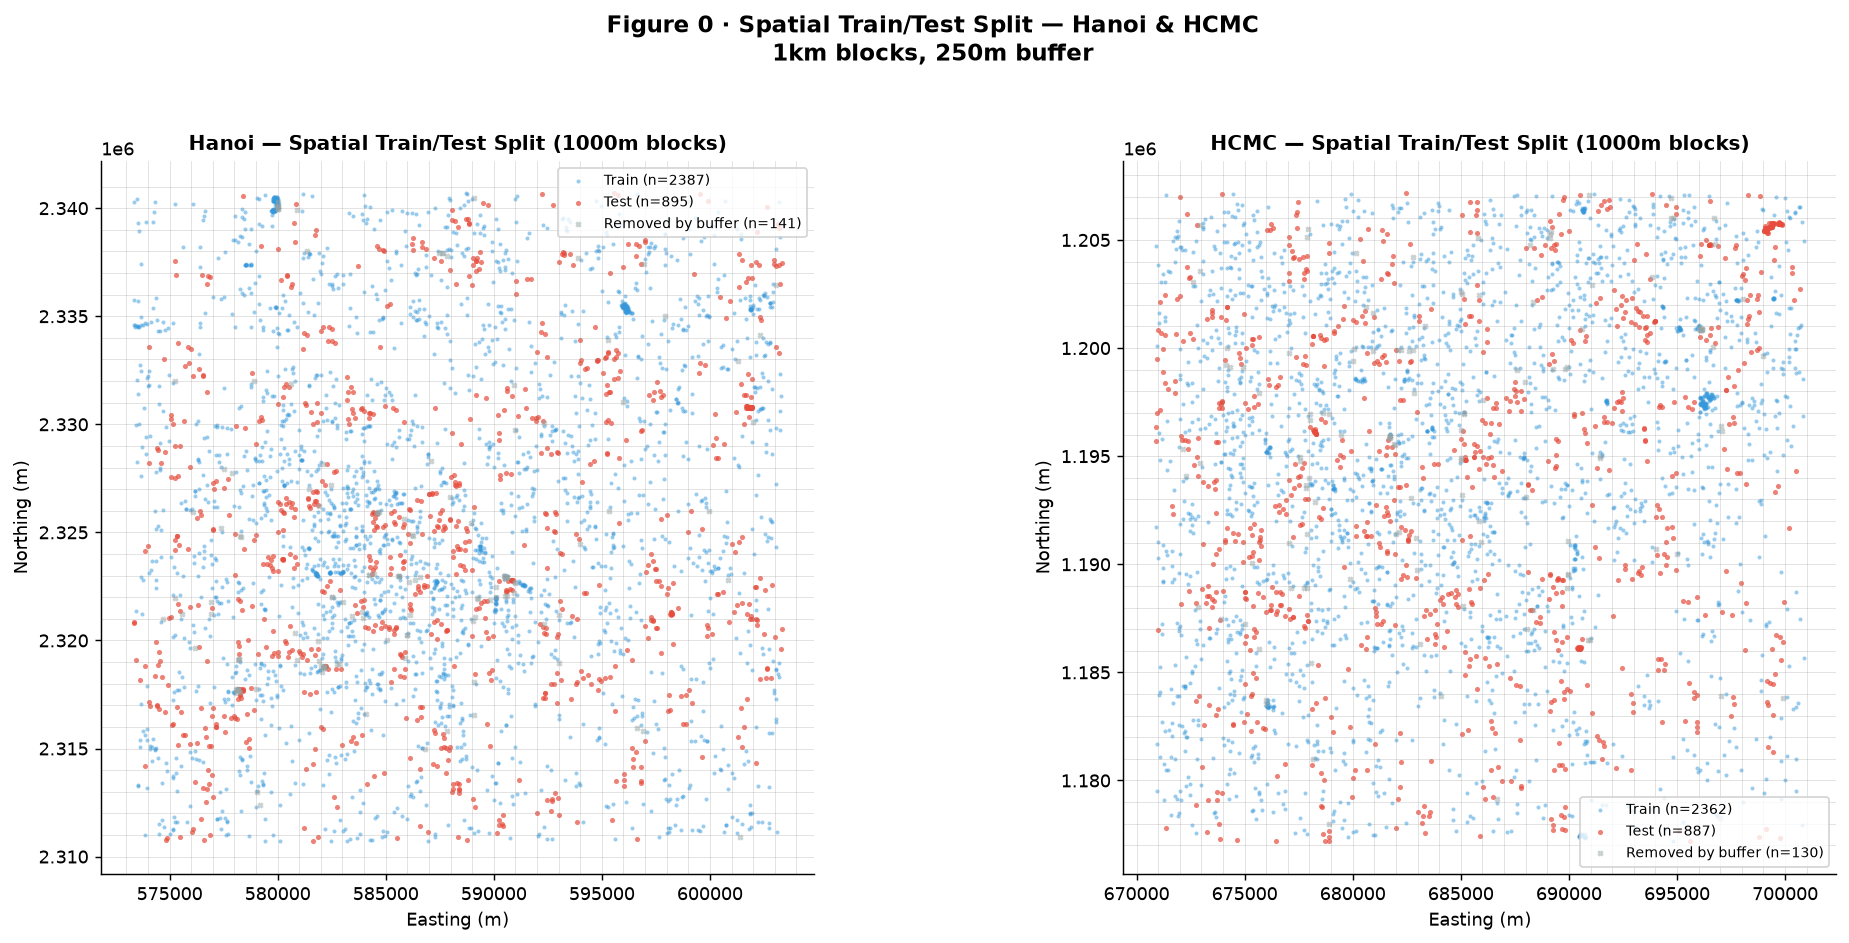

Figure 0 saved.


In [5]:
# Figure 0 -- Spatial train/test split per city
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (city_name, r) in zip(axes, city_results.items()):
    ct = r['coords_te']
    cr = r['coords_tr']
    # All test block points before buffer (reconstruct)
    smp_utm = city_results[city_name]['samples'].to_crs(CITIES[city_name]['utm_crs'])
    coords_all_c = np.column_stack([smp_utm.geometry.x, smp_utm.geometry.y])
    _, test_bm, keep = spatial_train_test_split(
        coords_all_c, 0.30, SPLIT_BLOCK_M, BUFFER_M, RANDOM_STATE)
    removed = coords_all_c[test_bm][~keep]

    ax.scatter(cr[:,0], cr[:,1], c='#3498db', s=5, alpha=0.5,
               linewidths=0, label=f'Train (n={len(cr)})')
    ax.scatter(ct[:,0], ct[:,1], c='#e74c3c', s=8, alpha=0.7,
               linewidths=0, label=f'Test (n={len(ct)})')
    if len(removed):
        ax.scatter(removed[:,0], removed[:,1], c='#95a5a6', s=6, alpha=0.5,
                   marker='x', label=f'Removed by buffer (n={len(removed)})')

    # Draw 1km grid
    x0, x1 = coords_all_c[:,0].min(), coords_all_c[:,0].max()
    y0, y1 = coords_all_c[:,1].min(), coords_all_c[:,1].max()
    for x in np.arange(x0//SPLIT_BLOCK_M*SPLIT_BLOCK_M, x1+SPLIT_BLOCK_M, SPLIT_BLOCK_M):
        ax.axvline(x, color='grey', lw=0.3, alpha=0.4)
    for y_v in np.arange(y0//SPLIT_BLOCK_M*SPLIT_BLOCK_M, y1+SPLIT_BLOCK_M, SPLIT_BLOCK_M):
        ax.axhline(y_v, color='grey', lw=0.3, alpha=0.4)

    ax.set_title(f'{city_name} — Spatial Train/Test Split ({SPLIT_BLOCK_M}m blocks)',
                 fontweight='bold')
    ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
    ax.set_aspect('equal'); ax.legend(fontsize=8)

fig.suptitle(f'Figure 0 · Spatial Train/Test Split — Hanoi & HCMC\n' +
             f'1km blocks, {BUFFER_M}m buffer',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig00_spatial_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 0 saved.')


---
## Cell 4 · Final comparison table — Milan vs Hanoi vs HCMC

In [6]:
rows = [{
    'Scenario':  'Milan (baseline)',
    'City':      'Milan',
    'Approach':  'Train + test on CLMS (spatial split)',
    'RMSE':      round(milan_meta['holdout_rmse'], 2),
    'MAE':       round(milan_meta['holdout_mae'], 2),
    'R2':        round(milan_meta['holdout_r2'], 3),
    'Bias':      round(milan_meta['holdout_bias'], 2),
}]
for cn, r in city_results.items():
    rows.append({
        'Scenario': 'A - Milan model transfer',
        'City':     cn,
        'Approach': 'Milan model -> GHSL spatial test',
        'RMSE':     round(r['metrics_zs']['RMSE'], 2),
        'MAE':      round(r['metrics_zs']['MAE'], 2),
        'R2':       round(r['metrics_zs']['R2'], 3),
        'Bias':     round(r['metrics_zs']['Bias'], 2),
    })
    rows.append({
        'Scenario': 'B - Local retrain',
        'City':     cn,
        'Approach': f'GHSL spatial train -> spatial test (CV block={r["best_cv_block"]}m)',
        'RMSE':     round(r['metrics_lr']['RMSE'], 2),
        'MAE':      round(r['metrics_lr']['MAE'], 2),
        'R2':       round(r['metrics_lr']['R2'], 3),
        'Bias':     round(r['metrics_lr']['Bias'], 2),
    })
comp_df = pd.DataFrame(rows)
comp_df.to_csv(f'{OUTPUT_DIR}/transferability_comparison.csv', index=False)

print('='*70)
print('   TRANSFERABILITY COMPARISON')
print('='*70)
print(comp_df.to_string(index=False))
print('='*70)

# Also print best CV block per city
for cn, r in city_results.items():
    print(f'  {cn}: best spatial CV block = {r["best_cv_block"]}m  ' +
          f'(tune CV RMSE={r["cv_rmse_tune"]:.3f}%)')


   TRANSFERABILITY COMPARISON
                Scenario  City                                            Approach  RMSE   MAE     R2   Bias
        Milan (baseline) Milan                Train + test on CLMS (spatial split) 11.29  7.82  0.896   0.05
A - Milan model transfer Hanoi                    Milan model -> GHSL spatial test 37.15 28.93 -0.142 -23.79
       B - Local retrain Hanoi  GHSL spatial train -> spatial test (CV block=500m) 24.05 18.49  0.522  -2.08
A - Milan model transfer  HCMC                    Milan model -> GHSL spatial test 35.19 26.98  0.042 -23.18
       B - Local retrain  HCMC GHSL spatial train -> spatial test (CV block=2000m) 22.88 17.93  0.595  -1.90
  Hanoi: best spatial CV block = 500m  (tune CV RMSE=24.188%)
  HCMC: best spatial CV block = 2000m  (tune CV RMSE=23.599%)


---
## Cell 4b · Figure 1 — Metric bar chart

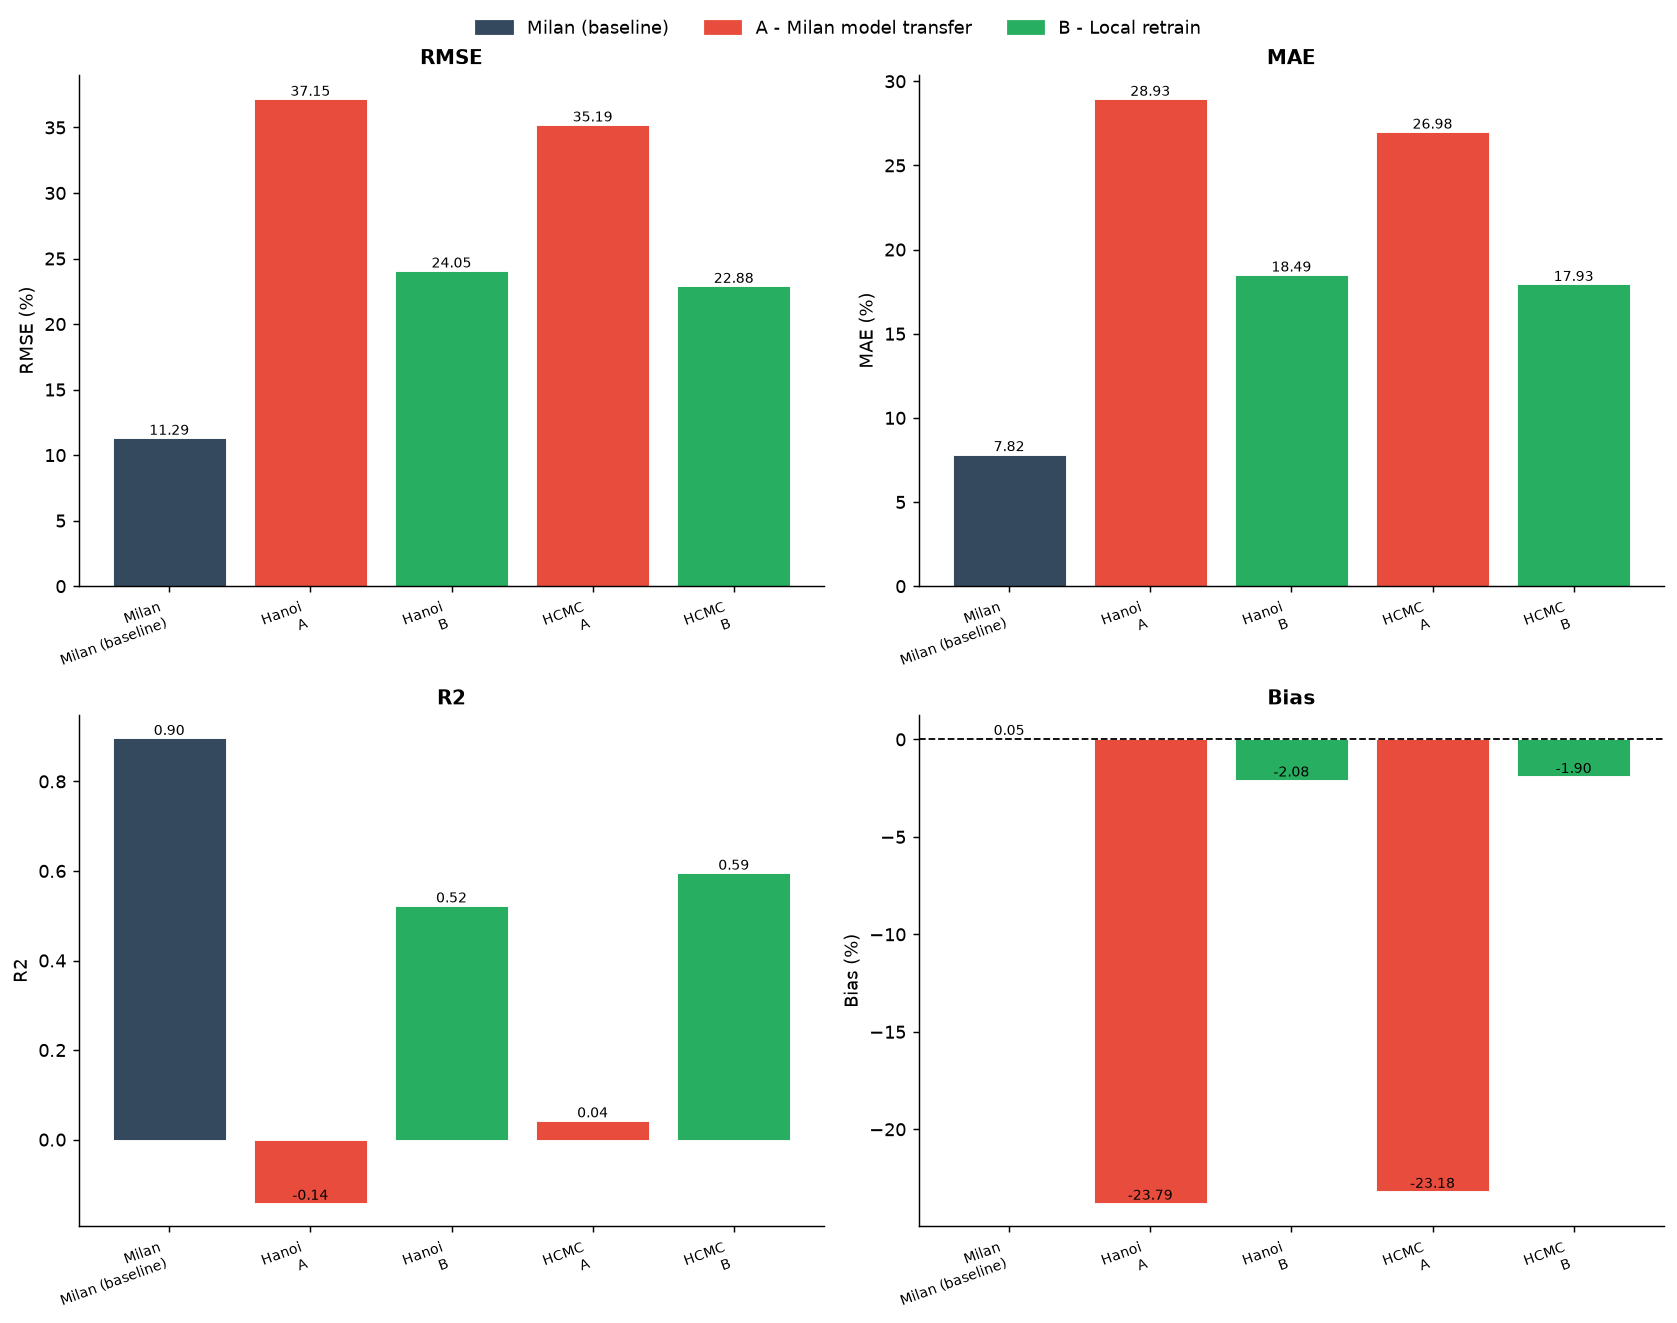

Figure 1 saved.


In [7]:
# Figure 1 -- Bar chart of metrics
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

metrics_to_plot = ['RMSE', 'MAE', 'R2', 'Bias']
ylabels         = ['RMSE (%)', 'MAE (%)', 'R2', 'Bias (%)']
scenario_colors = {
    'Milan (baseline)':         '#34495e',
    'A - Milan model transfer': '#e74c3c',
    'B - Local retrain':        '#27ae60',
}

for ax, metric, ylabel in zip(axes, metrics_to_plot, ylabels):
    bar_colors = [scenario_colors[s] for s in comp_df['Scenario']]
    labels = [f'{r["City"]}\n{r["Scenario"].split("-")[0].strip()}' for _, r in comp_df.iterrows()]
    bars = ax.bar(range(len(comp_df)), comp_df[metric],
                  color=bar_colors, edgecolor='white', linewidth=0.5)
    if metric == 'Bias':
        ax.axhline(0, color='black', lw=1, ls='--')
    for bar, val in zip(bars, comp_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(comp_df)))
    ax.set_xticklabels(labels, fontsize=8, rotation=20, ha='right')
    ax.set_ylabel(ylabel); ax.set_title(metric, fontweight='bold')

patches = [mpatches.Patch(color=col, label=sc) for sc, col in scenario_colors.items()]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=3, fontsize=10, frameon=False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig01_transfer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')


---
## Cell 5 · Per-city scatter plots — Milan transfer vs local retrain

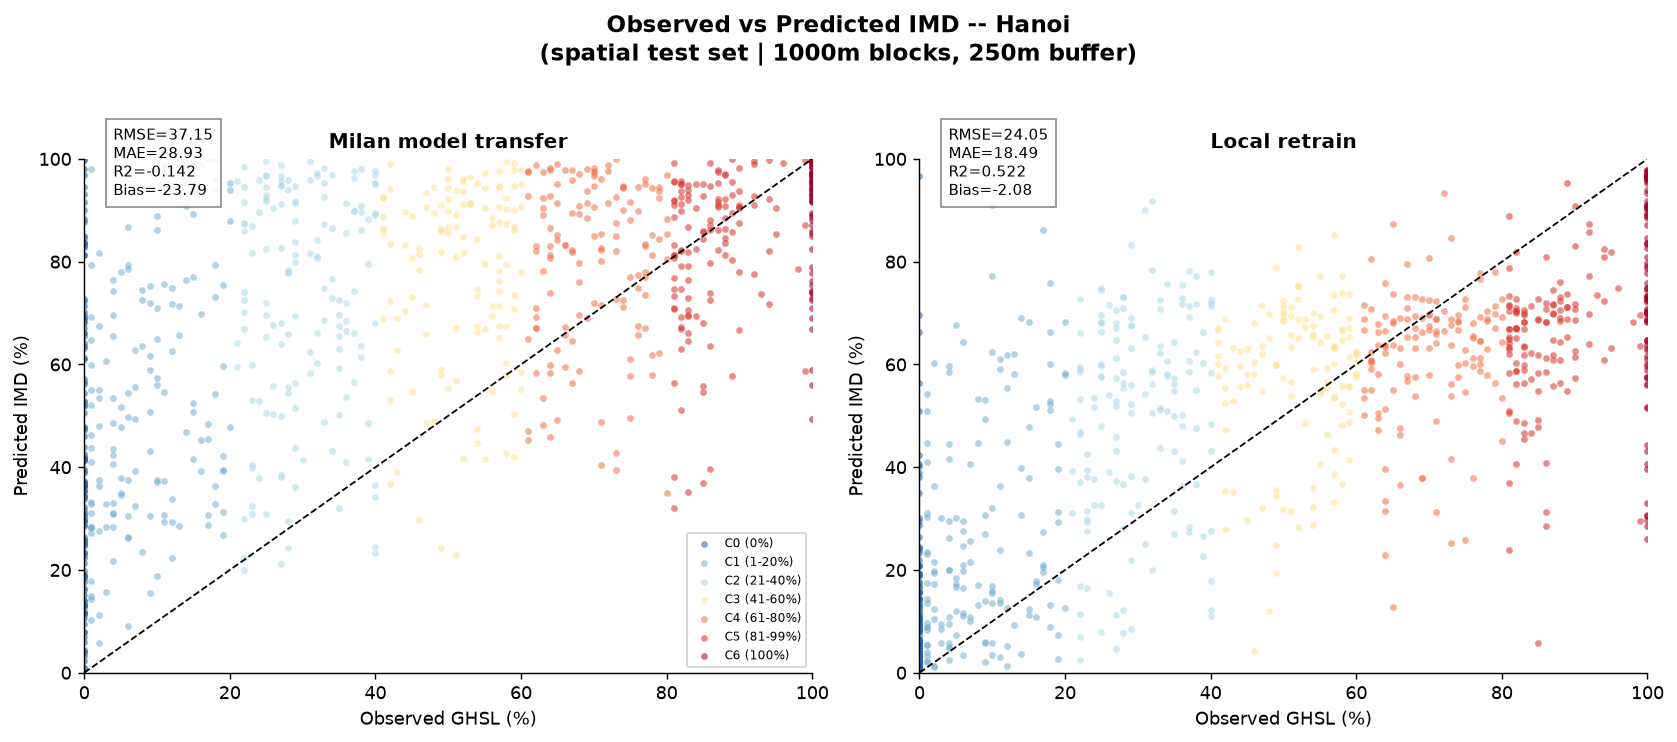

Scatter saved for Hanoi.


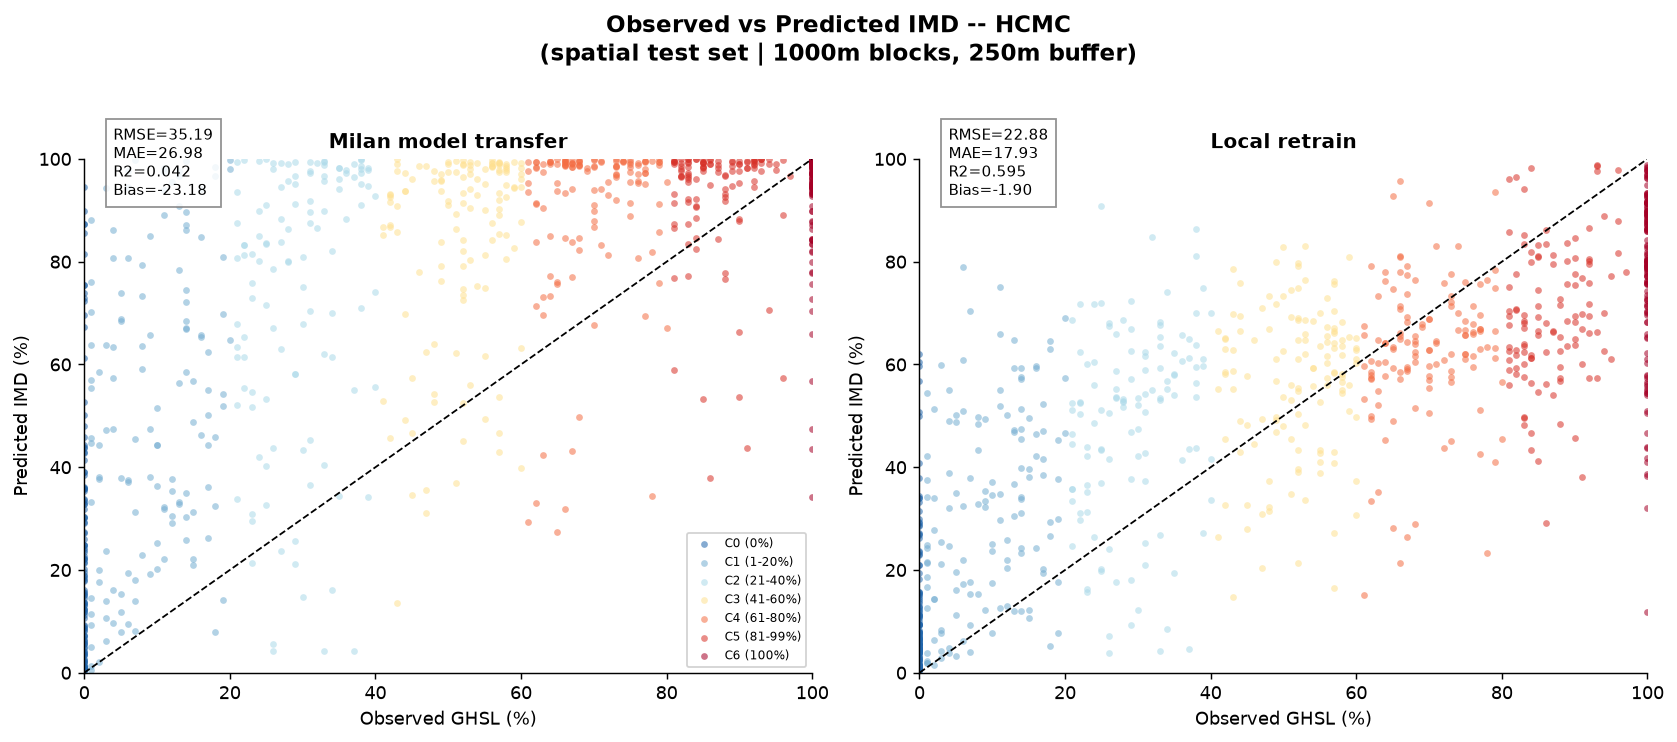

Scatter saved for HCMC.


In [8]:
# Figure -- Obs vs Pred scatter per city
for city_name, r in city_results.items():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    for ax, (label, y_pred, metrics) in zip(
        axes,
        [('Milan model transfer', r['y_pred_zs'], r['metrics_zs']),
         ('Local retrain',        r['y_pred_lr'], r['metrics_lr'])]
    ):
        for c in sorted(np.unique(r['cls_te'])):
            m = r['cls_te'] == c
            ax.scatter(r['y_te'][m], y_pred[m], c=CLASS_COLORS[c],
                       s=14, alpha=0.55, linewidths=0, label=CLASS_LABELS[c])
        ax.plot([0,100],[0,100],'k--',lw=1)
        ax.set_xlim(0,100); ax.set_ylim(0,100)
        ax.set_xlabel('Observed GHSL (%)'); ax.set_ylabel('Predicted IMD (%)')
        ax.set_title(label, fontweight='bold')
        ax.text(0.04, 0.93,
                f'RMSE={metrics["RMSE"]:.2f}\nMAE={metrics["MAE"]:.2f}\n' +
                f'R2={metrics["R2"]:.3f}\nBias={metrics["Bias"]:+.2f}',
                transform=ax.transAxes, fontsize=8.5,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='grey'))
    axes[0].legend(fontsize=6.5, framealpha=0.85, loc='lower right')
    fig.suptitle(f'Observed vs Predicted IMD -- {city_name}\n' +
                 f'(spatial test set | {SPLIT_BLOCK_M}m blocks, {BUFFER_M}m buffer)',
                 fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig_scatter_{city_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Scatter saved for {city_name}.')


---
## Cell 6 · Per-class metrics per city

 City             Scenario  Class   N  RMSE   MAE      R2   Bias
Hanoi Milan model transfer      0 131 50.03 42.35     NaN -42.35
Hanoi Milan model transfer      1 147 49.82 44.14 -67.240 -44.14
Hanoi Milan model transfer      2 148 47.00 41.91 -65.131 -41.16
Hanoi Milan model transfer      3 123 31.34 27.90 -28.212 -25.19
Hanoi Milan model transfer      4 132 19.41 16.44 -10.638  -9.75
Hanoi Milan model transfer      5 123 15.04 10.69 -10.018   4.00
Hanoi Milan model transfer      6  91 13.75  8.07     NaN   8.07
Hanoi                Local      0 131 19.42 12.43     NaN -12.43
Hanoi                Local      1 147 27.78 20.54 -20.221 -18.77
Hanoi                Local      2 148 28.03 24.52 -22.516 -19.73
Hanoi                Local      3 123 16.19 13.95  -6.792  -5.46
Hanoi                Local      4 132 15.67 11.27  -6.581   8.17
Hanoi                Local      5 123 25.22 21.85 -29.980  21.60
Hanoi                Local      6  91 32.41 26.16     NaN  26.16
 HCMC Milan model transfe

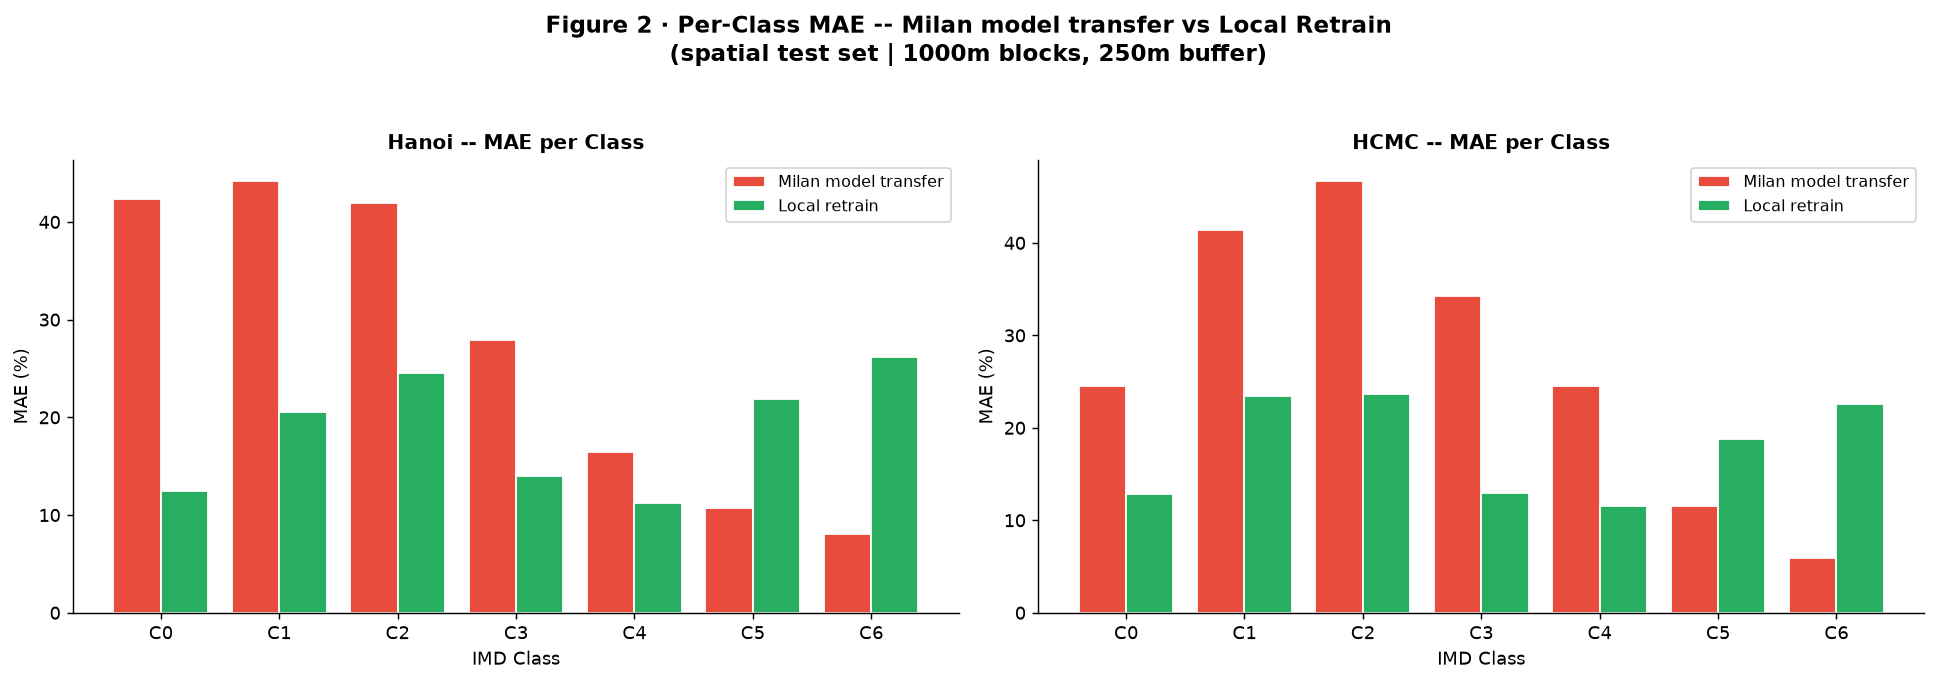

In [9]:
per_class_rows = []
for city_name, r in city_results.items():
    for scen_name, y_pred in [('Milan model transfer', r['y_pred_zs']),
                               ('Local', r['y_pred_lr'])]:
        for c in range(N_CLASSES):
            m = r['cls_te'] == c
            if m.sum() < 2:
                continue
            obs_c = r['y_te'][m]; pred_c = y_pred[m]
            per_class_rows.append({
                'City':     city_name,
                'Scenario': scen_name,
                'Class':    c,
                'N':        int(m.sum()),
                'RMSE':     round(float(np.sqrt(mean_squared_error(obs_c, pred_c))), 2),
                'MAE':      round(float(mean_absolute_error(obs_c, pred_c)), 2),
                # R2 within a single IMD class: the class restricts the observed
                # range, so the variance being explained is small and R2 goes
                # sharply negative for a modest offset. That is informative, not
                # a bug -- but it is NOT comparable to the global R2, and a class
                # whose observations are all identical has no variance at all,
                # leaving R2 undefined rather than 0.
                'R2':       (round(float(r2_score(obs_c, pred_c)), 3)
                             if np.ptp(obs_c) > 0 else np.nan),
                'Bias':     round(float(np.mean(obs_c - pred_c)), 2),
            })
per_cls_df = pd.DataFrame(per_class_rows)
per_cls_df.to_csv(f'{OUTPUT_DIR}/per_class_metrics.csv', index=False)
print(per_cls_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, city_name in zip(axes, city_results.keys()):
    sub     = per_cls_df[per_cls_df['City'] == city_name]
    classes = sorted(sub['Class'].unique())
    x_pos   = np.array(classes, dtype=float)
    width   = 0.4
    zs_mae  = [sub[(sub['Class']==c)&(sub['Scenario']=='Milan model transfer')]['MAE'].values for c in classes]
    lr_mae  = [sub[(sub['Class']==c)&(sub['Scenario']=='Local')]['MAE'].values for c in classes]
    zs_mae  = [v[0] if len(v) else 0 for v in zs_mae]
    lr_mae  = [v[0] if len(v) else 0 for v in lr_mae]
    ax.bar(x_pos - width/2, zs_mae, width, color='#e74c3c', label='Milan model transfer', edgecolor='white')
    ax.bar(x_pos + width/2, lr_mae, width, color='#27ae60', label='Local retrain', edgecolor='white')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'C{c}' for c in classes])
    ax.set_xlabel('IMD Class'); ax.set_ylabel('MAE (%)')
    ax.set_title(f'{city_name} -- MAE per Class', fontweight='bold')
    ax.legend(fontsize=9)
fig.suptitle('Figure 2 · Per-Class MAE -- Milan model transfer vs Local Retrain\n' +
             f'(spatial test set | {SPLIT_BLOCK_M}m blocks, {BUFFER_M}m buffer)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig02_per_class_mae.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Cell 7 · GEE full-raster predictions and export

In [10]:
# Milan RF params for GEE
milan_params = milan_meta['best_params']
print('Milan RF best params:', milan_params)

# The Milan TRAINING table for this predictor -- the 10 median bands, the
# same frozen split every S2 run shares.
milan_train = gpd.read_file(MILAN_TRAIN_PTS).dropna().reset_index(drop=True)
milan_train['IMD_class'] = milan_train['IMD_class'].astype(int)

milan_features = []
for _, row in milan_train.iterrows():
    props = {b: float(row[b]) for b in band_names}
    props['IMD'] = float(row['IMD'])
    milan_features.append(ee.Feature(
        ee.Geometry.Point([row.geometry.x, row.geometry.y]), props))
milan_fc = ee.FeatureCollection(milan_features)

mf = milan_params.get('max_features', 'sqrt')
if mf in ['sqrt', "'sqrt'"]:
    vps_m = max(1, int(np.sqrt(len(band_names))))
elif mf in ['log2', "'log2'"]:
    vps_m = max(1, int(np.log2(len(band_names))))
else:
    try: vps_m = max(1, int(float(str(mf).strip("'")) * len(band_names)))
    except: vps_m = 8

milan_rf_gee = (
    ee.Classifier.smileRandomForest(
        numberOfTrees     = int(str(milan_params.get('n_estimators', 200)).strip("''")),
        variablesPerSplit = vps_m,
        minLeafPopulation = int(str(milan_params.get('min_samples_leaf', 2)).strip("''")),
        bagFraction       = 0.8,
        seed              = RANDOM_STATE
    )
    .setOutputMode('REGRESSION')
    .train(features=milan_fc, classProperty='IMD', inputProperties=band_names)
)
print('GEE Milan RF ready')

for city_name, r in city_results.items():
    print(f'\n-- {city_name} GEE predictions --')
    # Local RF trained on spatial training set
    smp = r['samples']
    local_features = []
    for _, row in smp.iterrows():
        props = {b: float(row[b]) for b in band_names}
        props['IMD'] = float(row['IMD'])
        local_features.append(ee.Feature(
            ee.Geometry.Point([row.geometry.x, row.geometry.y]), props))
    local_fc = ee.FeatureCollection(local_features)

    bp  = r['best_params']
    mf  = bp.get('max_features', 'sqrt')
    vps_l = max(1, int(np.sqrt(len(band_names)))) if mf == 'sqrt' else             max(1, int(np.log2(len(band_names)))) if mf == 'log2' else             max(1, int(float(mf) * len(band_names)))

    local_rf_gee = (
        ee.Classifier.smileRandomForest(
            numberOfTrees     = bp.get('n_estimators', 200),
            variablesPerSplit = vps_l,
            minLeafPopulation = bp.get('min_samples_leaf', 2),
            bagFraction       = float(bp.get('max_samples', 0.8) or 0.8),
            seed              = RANDOM_STATE
        )
        .setOutputMode('REGRESSION')
        .train(features=local_fc, classProperty='IMD', inputProperties=band_names)
    )

    pred_zs = r['pred_img'].classify(milan_rf_gee).rename('IMD_predicted').clamp(0, 100)
    pred_lr = r['pred_img'].classify(local_rf_gee).rename('IMD_predicted').clamp(0, 100)

    for tag, image in [('zeroshot', pred_zs), ('localrf', pred_lr)]:
        task = ee.batch.Export.image.toDrive(
            image=image,
            description=f'IMD_{city_name}_{tag}_S2median',
            folder='GEE_IMD_exports_S2median',
            fileNamePrefix=f'IMD_{city_name}_10m_{tag}_S2median',
            region=r['aoi_ee'], scale=10, crs=r['utm_crs'],
            maxPixels=1e10, fileFormat='GeoTIFF'
        )
        task.start()
        print(f'  Submitted: IMD_{city_name}_{tag}')

print('\nAll export tasks submitted.')
print('Monitor at: https://code.earthengine.google.com/tasks')


Milan RF best params: {'bootstrap': 'True', 'ccp_alpha': '0.0', 'criterion': 'squared_error', 'max_depth': '30', 'max_features': '0.5', 'max_leaf_nodes': 'None', 'max_samples': '0.9', 'min_impurity_decrease': '0.0', 'min_samples_leaf': '1', 'min_samples_split': '2', 'min_weight_fraction_leaf': '0.0', 'monotonic_cst': 'None', 'n_estimators': '500', 'n_jobs': '-1', 'oob_score': 'False', 'random_state': '42', 'verbose': '0', 'warm_start': 'False'}
GEE Milan RF ready

-- Hanoi GEE predictions --


  Submitted: IMD_Hanoi_zeroshot


  Submitted: IMD_Hanoi_localrf

-- HCMC GEE predictions --


  Submitted: IMD_HCMC_zeroshot


  Submitted: IMD_HCMC_localrf

All export tasks submitted.
Monitor at: https://code.earthengine.google.com/tasks


---
## Cell 8 · Save final outputs

In [11]:
summary = {
    'milan_baseline': {
        'rmse': milan_meta['holdout_rmse'],
        'mae':  milan_meta['holdout_mae'],
        'r2':   milan_meta['holdout_r2'],
        'bias': milan_meta['holdout_bias'],
    }
}
for cn, r in city_results.items():
    summary[cn] = {
        'zero_shot':         r['metrics_zs'],
        'local_rf':          r['metrics_lr'],
        'best_cv_block_m':   r['best_cv_block'],
        'cv_rmse_tune':      r['cv_rmse_tune'],
        'n_samples_train':   len(r['train_idx']),
        'n_samples_test':    len(r['test_idx']),
        'buffer_removed':    int(r['block_mask_rem']),
    }
with open(f'{OUTPUT_DIR}/transfer_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('\n-- Final outputs --')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f'  {f:<45} {size/1024:>8.1f} kB')

print('\n== FINAL SUMMARY ==')
print(f'  Milan baseline RMSE: {milan_meta["holdout_rmse"]:.2f}%')
for cn, r in city_results.items():
    print(f'  {cn} | Split: {len(r["train_idx"])} train / {len(r["test_idx"])} test ' +
          f'| CV block={r["best_cv_block"]}m')
    print(f'       Scenario A (Milan transfer): RMSE={r["metrics_zs"]["RMSE"]:.2f}%  R2={r["metrics_zs"]["R2"]:.3f}')
    print(f'       Scenario B (Local retrain):  RMSE={r["metrics_lr"]["RMSE"]:.2f}%  R2={r["metrics_lr"]["R2"]:.3f}')



-- Final outputs --
  IMD_HCMC_10m_localrf_S2median.tif              36518.9 kB
  IMD_HCMC_10m_zeroshot_S2median.tif             32147.4 kB
  IMD_Hanoi_10m_localrf_S2median.tif             32798.2 kB
  IMD_Hanoi_10m_zeroshot_S2median.tif            32432.6 kB
  fig00_spatial_split.png                          335.2 kB
  fig01_transfer_comparison.png                    112.5 kB
  fig02_per_class_mae.png                           63.7 kB
  fig_obs_vs_pred_hanoi_hcmc.png                  5022.0 kB
  fig_scatter_HCMC.png                             189.9 kB
  fig_scatter_Hanoi.png                            193.8 kB
  local_rf_HCMC.joblib                            2119.8 kB
  local_rf_Hanoi.joblib                          22078.6 kB
  per_class_metrics.csv                              1.4 kB
  samples_HCMC_test.gpkg                           220.0 kB
  samples_HCMC_train.gpkg                          412.0 kB
  samples_Hanoi_test.gpkg                          232.0 kB
  samples_Hanoi_tra

---
## Cell 9 · Visualise predictions vs GHSL (after downloading GEE rasters)

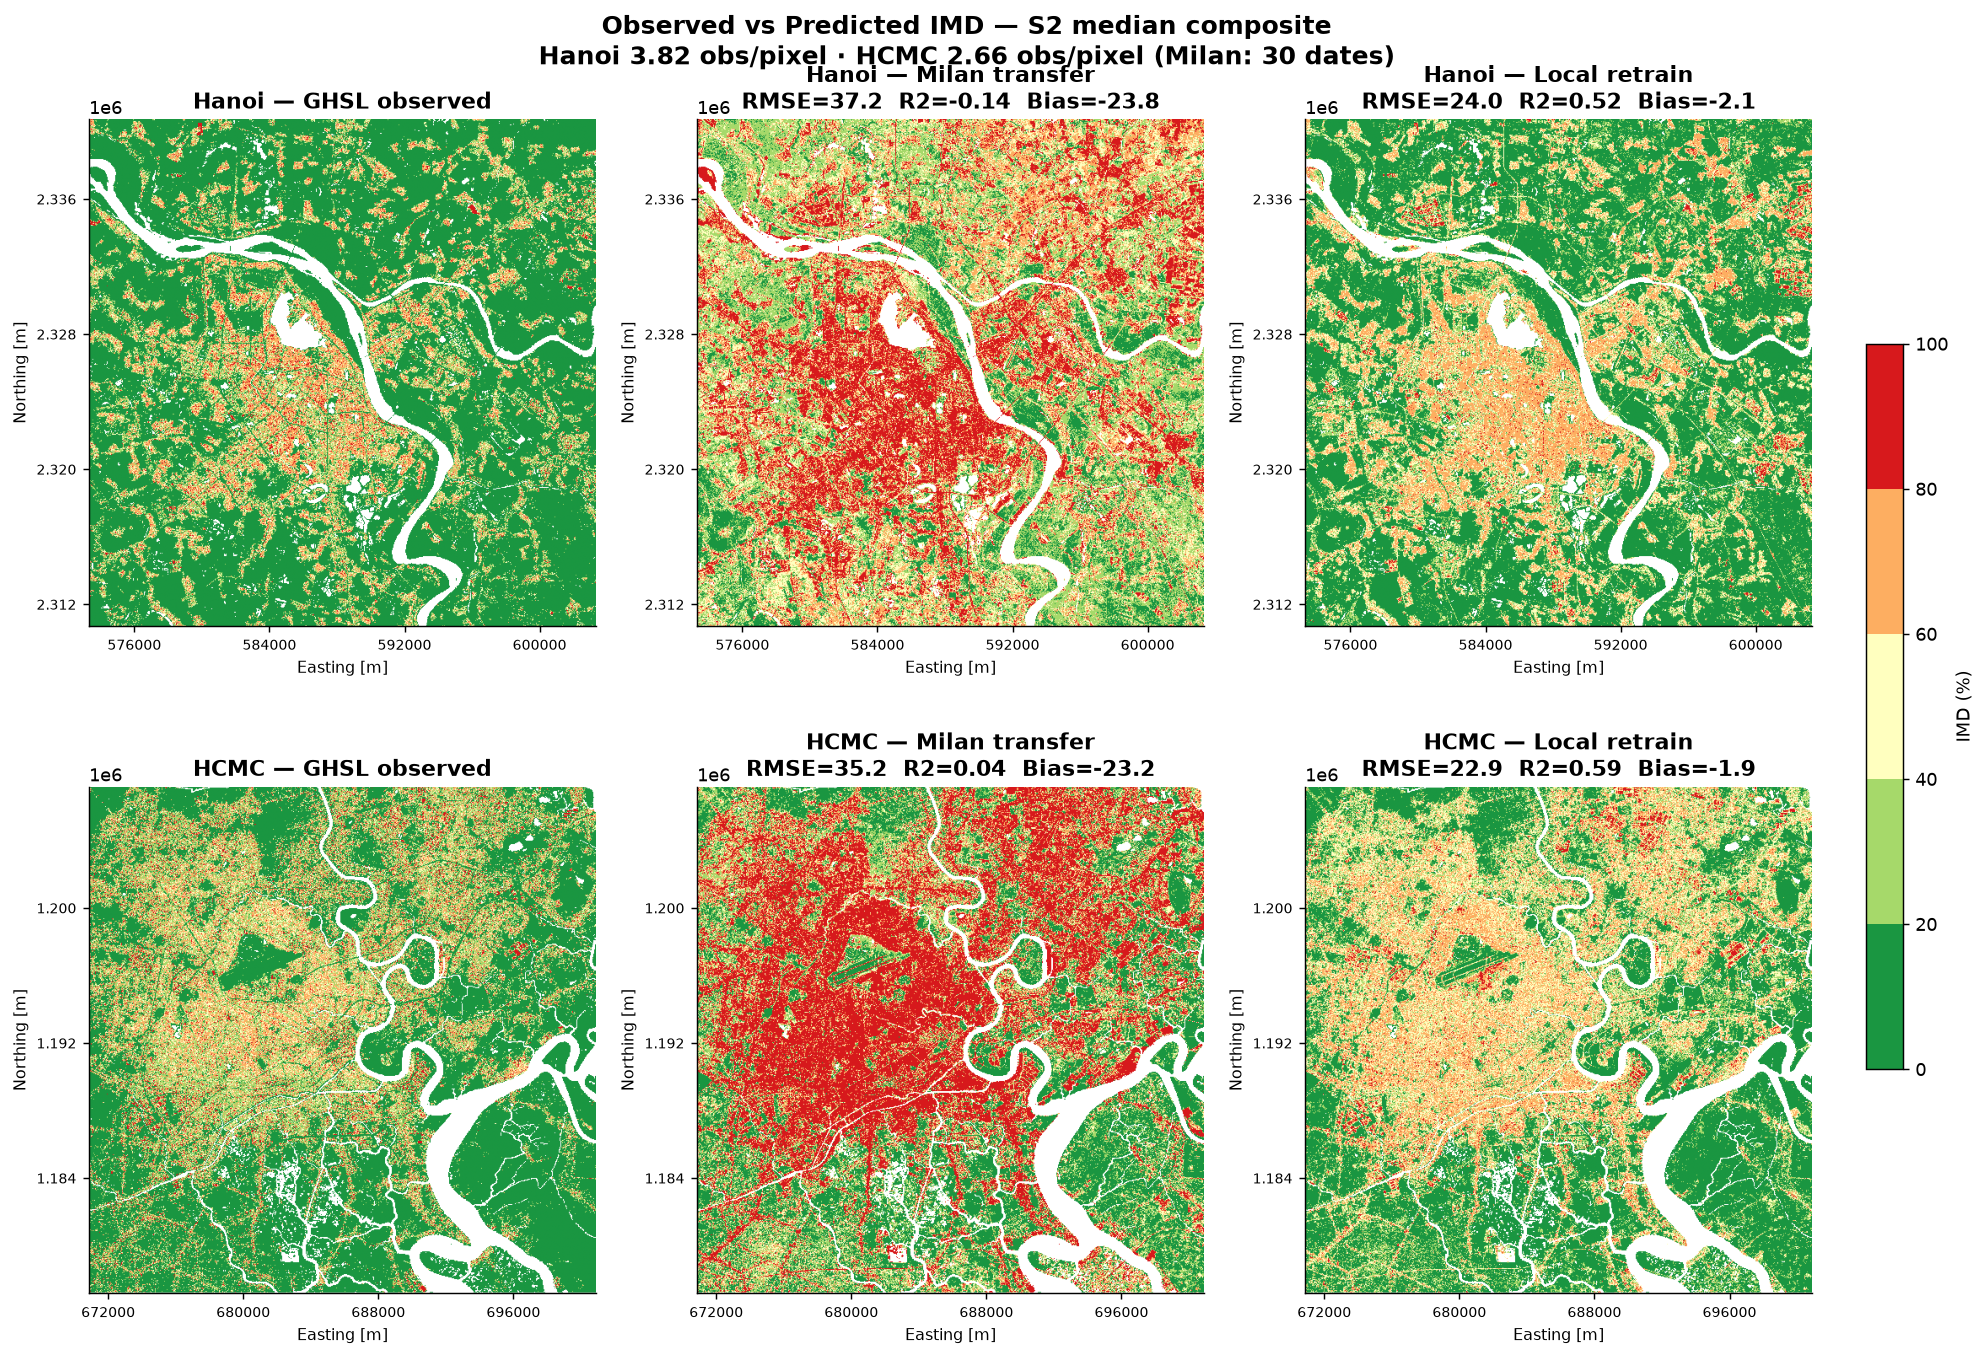

Saved ./outputs_transfer_S2_median/fig_obs_vs_pred_hanoi_hcmc.png


In [12]:
import matplotlib.ticker as mticker

# Both scenarios, both cities. The predicted rasters are ALREADY water-masked:
# build_composite applies the ESA WorldCover mask before the composite is
# classified, so masked pixels arrive as NaN (~6.5% of the Hanoi AOI). Notebook
# 02 read a separate ./outputs_transfer_*/water_mask_<city>.tif here, but
# nothing in either notebook ever wrote that file -- it was a manual GEE export
# that no longer exists. Masking GHSL with the prediction's own NaN footprint
# gives the same result and keeps the two panels directly comparable.
DISPLAY_SCALE = 5
imd_cmap = ListedColormap(IMD_PALETTE)

SCENARIOS = [('zeroshot', 'Milan transfer'), ('localrf', 'Local retrain')]


def imshow_aspect(ax, da, **kw):
    b = da.rio.bounds()
    im = ax.imshow(da.values, extent=(b[0], b[2], b[1], b[3]), **kw)
    ax.set_aspect('equal')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.tick_params(axis='both', labelsize=8)
    ax.set_xlabel('Easting [m]', fontsize=9)
    ax.set_ylabel('Northing [m]', fontsize=9)
    return im


fig, axes = plt.subplots(len(CITIES), 3, figsize=(18, 6 * len(CITIES)),
                         gridspec_kw={'wspace': 0.20, 'hspace': 0.25})
axes = np.atleast_2d(axes)

for row, (city, cfg) in enumerate(CITIES.items()):
    preds = {}
    for tag, _ in SCENARIOS:
        p = f'{OUTPUT_DIR}/IMD_{city}_10m_{tag}_S2median.tif'
        if not os.path.exists(p):
            raise FileNotFoundError(
                f'{p}\n'
                'Download the GEE exports from Drive into '
                f'{OUTPUT_DIR}/ first -- Cell 7 only submits the tasks.')
        preds[tag] = rxr.open_rasterio(p, masked=True).squeeze('band', drop=True)

    ref = preds['localrf']
    ghsl = rxr.open_rasterio(cfg['ghsl_path'], masked=True).squeeze('band', drop=True)
    if ghsl.rio.crs != ref.rio.crs:
        ghsl = ghsl.rio.reproject(ref.rio.crs)
    ghsl = ghsl.rio.clip_box(*ref.rio.bounds()).rio.reproject_match(ref)
    # Water comes from the prediction's own mask -- no external file needed.
    ghsl = ghsl.where(~np.isnan(ref))

    im = imshow_aspect(axes[row, 0], ghsl[::DISPLAY_SCALE, ::DISPLAY_SCALE],
                       cmap=imd_cmap, vmin=0, vmax=100)
    axes[row, 0].set_title(f'{city} — GHSL observed', fontweight='bold', fontsize=12)

    for col, (tag, label) in enumerate(SCENARIOS, start=1):
        r = city_results[city]
        m = r['metrics_zs'] if tag == 'zeroshot' else r['metrics_lr']
        im = imshow_aspect(axes[row, col],
                           preds[tag][::DISPLAY_SCALE, ::DISPLAY_SCALE],
                           cmap=imd_cmap, vmin=0, vmax=100)
        axes[row, col].set_title(
            f'{city} — {label}\n'
            f'RMSE={m["RMSE"]:.1f}  R2={m["R2"]:.2f}  '
            f'Bias={m["Bias"]:+.1f}', fontweight='bold', fontsize=12)

fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.03,
             label='IMD (%)')
# Composite depth read from each city's extraction metadata, not hardcoded:
# a literal here goes stale silently if the date screening changes.
_depth = []
for _c, _cfg in CITIES.items():
    with open(_cfg['dates_meta']) as _f:
        _dm = json.load(_f)
    _o = _dm.get('obs_per_pixel') or sum(
        d['valid%'] for d in _dm['per_date_stats']) / 100
    _depth.append(f'{_c} {_o:.2f} obs/pixel')
_milan_n = len(milan_meta['selected_dates'])
fig.suptitle('Observed vs Predicted IMD — S2 median composite\n'
             + ' · '.join(_depth) + f' (Milan: {_milan_n} dates)',
             fontsize=14, fontweight='bold', y=0.94)
plt.savefig(f'{OUTPUT_DIR}/fig_obs_vs_pred_hanoi_hcmc.png', dpi=150,
            bbox_inches='tight')
plt.show()
print(f'Saved {OUTPUT_DIR}/fig_obs_vs_pred_hanoi_hcmc.png')